In [3]:
from fastai.vision.all import *
from fastai.metrics import * 

# from pathlib import Path

from sklearn.model_selection import  train_test_split # GroupKFold, StratifiedGroupKFold, LeaveOneGroupOut, LeavePGroupsOut,
from sklearn.utils import resample
import sklearn.metrics as skm
# path = Path('/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/data/biliseq_he_class/proc/v6')
path = Path('/mnt/data/biliseq_he_class/proc/v6') #singularity --bind compatible (project dir to /mnt)
import numpy as np
from numpy import random
import shutil
import glob
import itertools 
import pandas as pd
import glob
import time
from matplotlib import pyplot as plt
# path.joinpath('summary_model').ls()

(#3) [Path('/mnt/data/biliseq_he_class/proc/v6/summary_model/resnet18_10fold10rep'),Path('/mnt/data/biliseq_he_class/proc/v6/summary_model/resnet18_10kfold'),Path('/mnt/data/biliseq_he_class/proc/v6/summary_model/resnet18_jackknife_v0')]

(#1) [Path('/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/data/biliseq_he_class/proc/v6/summary_model/resnet18_10kfold')]

In [ ]:
#Load model:
model_path = path/"tiles_model"/"resnet18_10fold10rep"
model = model_path.ls(file_exts='.pkl')
print(model[1])
learn = load_learner(model[1])


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/ihome/rbao/bri8/envs/fastai/lib/python3.8/site-packages/IPython/core/interactiveshell.py", line 3457, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-4-1075b025f8a0>", line 4, in <module>
    print(model[1])
  File "/ihome/rbao/bri8/envs/fastai/lib/python3.8/site-packages/fastcore/foundation.py", line 111, in __getitem__
    def __getitem__(self, idx): return self._get(idx) if is_indexer(idx) else L(self._get(idx), use_list=None)
  File "/ihome/rbao/bri8/envs/fastai/lib/python3.8/site-packages/fastcore/foundation.py", line 115, in _get
    if is_indexer(i) or isinstance(i,slice): return getattr(self.items,'iloc',self.items)[i]
IndexError: list index out of range

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/ihome/rbao/bri8/envs/fastai/lib/python3.8/site-packages/IPython/core/interactiveshell.py", line 2077, in showtraceback
    stb = v

In [ ]:
keys = learn.recorder.hps.keys()
print(keys)
print(np.min(learn.recorder.hps['lr']))

In [ ]:
learn.recorder.plot_sched()

In [ ]:
test = DataBlock(blocks=(ImageBlock, CategoryBlock),
                  get_items=get_image_files, 
                  splitter = None,
                  get_y= parent_label ,
                  batch_tfms=Resize(224),#using_attr(RegexLabeller(re_class), 'name')
                 )
new_dls=test.dataloaders(path/"model"/"test",bs=64)

# print(len(preds[0]),preds[0].sum())


In [ ]:
# MANUAL BATCH ITERATION METHODS:
# dir(new_dls)
# two_batch=itertools.islice(new_dls.train,3)
# batch=[]
# for x,y in new_dls.train:
#     batch.append((x,y))
#     # print(preds)
# len(batch)


In [ ]:
fns=path/"model"/"test"/"neg"
fn=fns.joinpath('1007466_class_neg_x33000_y8500.jpg')
fn=fns.parent.joinpath('pos').joinpath('1007476_class_pos_x61000_y149500.jpg')
out=learn.predict(fn)
print(out)
print(float(out[2].cpu()[0]))

In [ ]:

print(mdl[0])

In [6]:
#Create a dictionary to use for generating panads dataframe:
# densenet121
use_models=['alexnet_1100','alexnet_170','alexnet110']
mdl_preds = {'fn':[],
             'slide':[],
             'class':[],
             'ensemble_p0':[],
             'ensemble_class':[],
            }
for mdl in use_models:
    mdl_preds['%s_p0' % mdl]=[]
    mdl_preds['%s_class' % mdl]=[]
    
fns=glob.glob(str(path.joinpath("model/test/**/*.jpg")),recursive=True)

# fns= resample(fns, n_samples=50)
model_path = path/"model"/"export"
mdls = model_path.ls(file_exts='.pkl')

t=time.time()
for i,mdl in enumerate(use_models):    
    #Load model    
    mdlfn = [m for m in mdls if mdl in str(m)]
    print('Loading %s' % mdlfn[0])
    learn = load_learner(mdlfn[0])
    
    #Run inference on test set
    for fn in fns:
        f=Path(fn).parts[-1]
        if i == 0:           
            mdl_preds['fn'].append(f)
            mdl_preds['slide'].append(f.split('_')[0])
            mdl_preds['class'].append(Path(fn).parts[-2])
        out=learn.predict(fn)
        p_neg = float(out[2].cpu()[0]) #change this to return p(pos)
        p_class = out[0]
        mdl_preds['%s_p0' % mdl].append( p_neg)
        mdl_preds['%s_class' % mdl].append( p_class)
        print('\t%s predict %s as %s' % (mdl,f,p_class))
classes=['pos','neg']
mdl_weights=[1, 1, 1]
for i in range(0,len(mdl_preds['fn'])):
    p=0
    for mdl in use_models:
         p+= mdl_preds['%s_p0' % mdl][i]
    p= p/len(use_models) #Currently weights all models equally
    mdl_preds['ensemble_p0'].append(p)
    mdl_preds['ensemble_class'].append(classes[int(p>0.5)])

df=pd.DataFrame(mdl_preds)


s=time.time()
df.to_csv(path.joinpath('model').joinpath('rs_42_test_pred_2021-12-16_alexnet_110_1100_170.csv'))
print('%ds to process %d files' % (s-t, len(mdl_preds['fn'])))

Loading /ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/data/biliseq_he_class/proc/v5/model/export/alexnet_11004142t_bs512_maxrot45_minscale_0p75_1frz_100ftune.pkl


	alexnet_1100 predict 1007467_class_neg_x26500_y87500.jpg as pos


	alexnet_1100 predict 1007821_class_neg_x20500_y9000.jpg as neg


	alexnet_1100 predict 1007466_class_neg_x7500_y87000.jpg as neg


	alexnet_1100 predict 1007466_class_neg_x27500_y7000.jpg as pos


...

	alexnet_170 predict 1007831_class_pos_x13000_y198500.jpg as pos


	alexnet_170 predict 1007476_class_pos_x14500_y47500.jpg as pos


	alexnet_170 predict 1007831_class_pos_x24000_y123000.jpg as neg


	alexnet_170 predict 1007831_class_pos_x19500_y120000.jpg as pos


IndexError: list index out of range

In [4]:
df1=pd.read_csv(path.joinpath('model').joinpath('rs_42_test_pred_2021-12-16_xrn50_220.csv'))
df2=pd.read_csv(path.joinpath('model').joinpath('rs_42_test_pred_2021-12-16_rn18_15_rn34_225.csv'))
df=pd.concat((df1,df2.loc[:,('resnet18_15_p0','resnet18_15_class')]),axis=1)

In [140]:
df=pd.read_csv(path.joinpath('model').joinpath('rs_42_test_pred_2021-12-15_3mdls.csv'))
df.head()f

,Unnamed: 0,fn,slide,class,ensemble_p0,ensemble_class,resnet34_p0,resnet34_class,xresnet50_p0,xresnet50_class,densenet121_p0,densenet121_class
0,0,1007467_class_neg_x26500_y87500.jpg,1007467,neg,0.639954,neg,0.929972,neg,0.000000e+00,pos,0.989890,neg
1,1,1007821_class_neg_x20500_y9000.jpg,1007821,neg,0.662633,neg,0.993095,neg,2.420356e-23,pos,0.994805,neg
2,2,1007466_class_neg_x7500_y87000.jpg,1007466,neg,0.516539,neg,0.830284,neg,0.000000e+00,pos,0.719333,neg
3,3,1007466_class_neg_x27500_y7000.jpg,1007466,neg,0.965309,neg,0.929595,neg,1.000000e+00,neg,0.966332,neg
4,4,1007466_class_neg_x27000_y5500.jpg,1007466,neg,0.079517,pos,0.024904,pos,0.000000e+00,pos,0.213649,pos


In [138]:
use_models

['resnet18_15', 'resnet34_225']

In [5]:
#Generate slide-level predictions with each model & ensemble
test_slides=np.unique(df.loc[:,('slide')])
# use_models=['resnet34_4142t','resnet18','xresnet34',]
use_models=['resnet18_15','xresnet50_2255']
use_thresh=[0.5,0.7]
wsi_preds = {'slide':[],             
             'ensemble_p0':[],
             'ensemble_p0class':[],
             'ensemble_wta':[],
             'class':[],
            }
for mdl in use_models:
    wsi_preds['%s_p0' % mdl]=[]
    wsi_preds['%s_wta' % mdl]=[]
    wsi_preds['%s_npos' % mdl]=[]
    
classes=['pos','neg']
# thresh=[0.5,0.7]
for slide in test_slides:
    ens_wta=[]
    mdl_p=[]
    wsi_preds['slide'].append(slide)
    idx = df.loc[:,'slide']==slide
    first=np.argwhere(np.array(idx)==True)[0][0]
    wsi_preds['class'].append(df.loc[first,'class'])
    for mdl,thresh in zip(use_models,use_thresh):
        col= '%s_p0' % mdl        
        n = np.sum(idx)
        total_p = np.sum(df.loc[idx,col])/n
        n_pos = np.sum(df.loc[idx,col] < thresh)
        wsi_preds[col].append(total_p)
        wsi_preds['%s_npos' % mdl].append(n_pos/n)
        mdl_p.append(total_p)
        
        wta_col='%s_wta' % mdl
        df_col='%s_class' % mdl
        if np.sum(df.loc[idx,df_col]=='neg') > np.sum(df.loc[idx,df_col]=='pos'):
            c='neg'
            ens_wta.append(1)
        else:
            c='pos'
            ens_wta.append(0)
        wsi_preds[wta_col].append(c)
    p=sum(mdl_p)/len(use_models)
    wsi_preds['ensemble_p0'].append(p)
    wsi_preds['ensemble_p0class'].append(classes[int(p>0.5)])
    wsi_preds['ensemble_wta'].append(classes[np.mean(ens_wta)>0.5])
wsi_df=pd.DataFrame(wsi_preds)
wsi_df.head(8)
        
        

<ipython-input-5-2c88ea6e3337>:47: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
  wsi_preds['ensemble_wta'].append(classes[np.mean(ens_wta)>0.5])


,slide,ensemble_p0,ensemble_p0class,ensemble_wta,class,resnet18_15_p0,resnet18_15_wta,resnet18_15_npos,xresnet50_2255_p0,xresnet50_2255_wta,xresnet50_2255_npos
0,1007466,0.472860,pos,pos,neg,0.511336,neg,0.488281,0.434384,pos,0.699219
1,1007467,0.793219,neg,neg,neg,0.742078,neg,0.187773,0.844361,neg,0.196507
2,1007471,0.749506,neg,neg,neg,0.864188,neg,0.103448,0.634824,neg,0.482759
3,1007476,0.767385,neg,neg,pos,0.736201,neg,0.237942,0.798568,neg,0.231511
4,1007477,0.726860,neg,neg,pos,0.673653,neg,0.270531,0.780067,neg,0.260870
5,1007485,0.304504,pos,pos,pos,0.398342,pos,0.640000,0.210665,pos,0.906667
6,1007821,0.746715,neg,neg,neg,0.770218,neg,0.165414,0.723212,neg,0.372180
7,1007831,0.496223,pos,pos,pos,0.497016,pos,0.501174,0.495430,neg,0.644366


[[4 0]
 [2 2]]


Text(0.5, 1.0, 'AUROC 0.812, Sensitivity: 0.50, Specificity: 1.00')

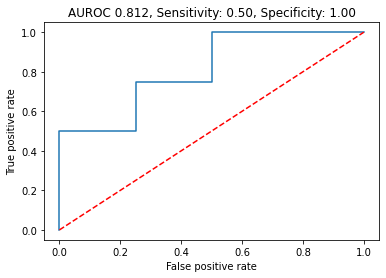

In [121]:
y_pred = np.array(wsi_df.loc[:,'resnet34_wta']) == 'pos'
y_true = np.array(wsi_df.loc[:,'class'])=='pos'
                  
fpr,tpr,thresh=skm.roc_curve(y_true,
              1-np.array(wsi_df.loc[:,'resnet34_p0']))
c=skm.confusion_matrix(y_true,y_pred)
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],'--r')

auc=skm.auc(fpr,tpr)

plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
print(c)
tn=c[0][0]
tp=c[1][1]
fn=c[1][0]
fp=c[0][1]

sensitivity = tp/(tp + fn) #True pos / all positive
# print('sensitivity',sensitivity)

specificity = tn/(fp + tn)
# print('specificity',specificity) #True neg / all negative
plt.title('AUROC %1.3f, Sensitivity: %1.2f, Specificity: %1.2f'% (auc,sensitivity,specificity))

In [112]:
tpr[-1]

1.0

In [1]:
help(learn.dls.test_dl)

NameError: name 'learn' is not defined